# Used cars

## EDA

### Libraries

In [92]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

### Dataset

In [93]:
df = pd.read_csv('../Datasets/carros_usados.csv')

### Variable breakdown

- Model: The make and model of the car.
- Year: The year the car was manufactured.
- Price: The selling price of the car.
- Transmission: The type of transmission (e.g., automatic, manual).
- Mileage: The distance the car has traveled, usually measured in miles or kilometers.
- Fuel Type: The type of fuel the car uses (e.g., petrol, diesel, electric).
- Tax: The amount of tax applicable to the car.
- mpg: Miles per gallon, a measure of fuel efficiency.
- engineSize: The size of the car's engine, usually measured in liters.
- make: The manufacturer of the car (e.g., Ford, Toyota).

In [94]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  object 
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  object 
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  object 
 6   tax           72435 non-null  float64
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 5.5+ MB


==> there are no missing values in the dataset

==> ['transmission', 'fuelType', 'make'] need to be encoded

**==> What about 'model'?**

In [96]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16580.158708,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.028754,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


In [97]:
df.describe(exclude='number')

,model,transmission,fuelType,Make
count,72435,72435,72435,72435
unique,146,4,5,7
top,Fiesta,Manual,Petrol,Ford
freq,6556,43021,40370,17964


==> model has 205 unique values, which is too many for one-hot encoding. We can either drop it or use target encoding.

==> transmission, fuelType, and make have a small number of unique values, so we can use one-hot encoding for them.

==> this is an unbalanced dataset, with most cars being petrol and automatic. We can use stratified sampling to ensure that our training and test sets have a similar distribution of these variables.

In [98]:
df.nunique()

model             146
year               25
price           10418
transmission        4
mileage         35743
fuelType            5
tax                47
mpg               177
engineSize         32
Make                7
dtype: int64

In [99]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

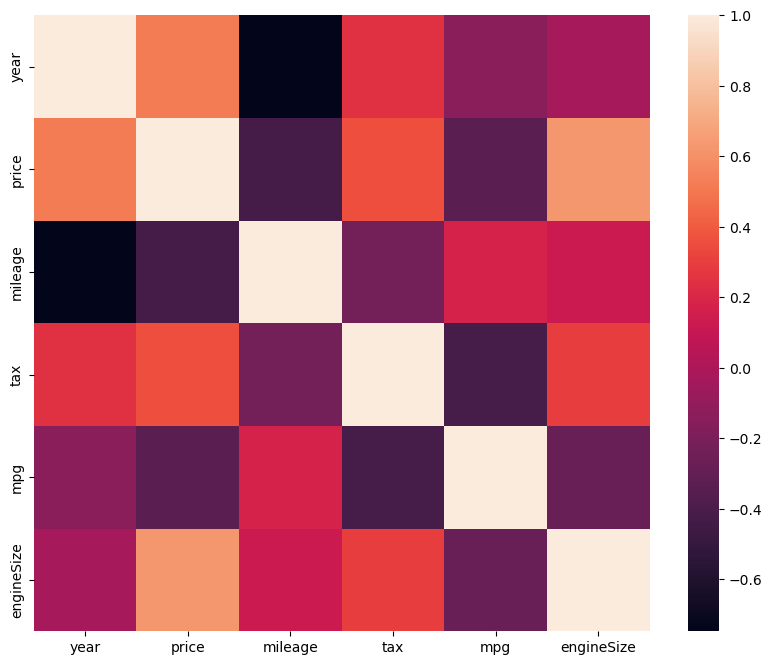

In [100]:
# Identify correlations between numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), square = True)
plt.show()

==> **What can we conclude from this?**

Very few cars are electric, so we won't be able to predict the price of electric cars accurately. We can either drop the electric cars from our dataset or use a different model that can handle unbalanced datasets, such as XGBoost.

==> Drop 'model' and 'tax' from our dataset, as they are not useful for predicting the price of the car.

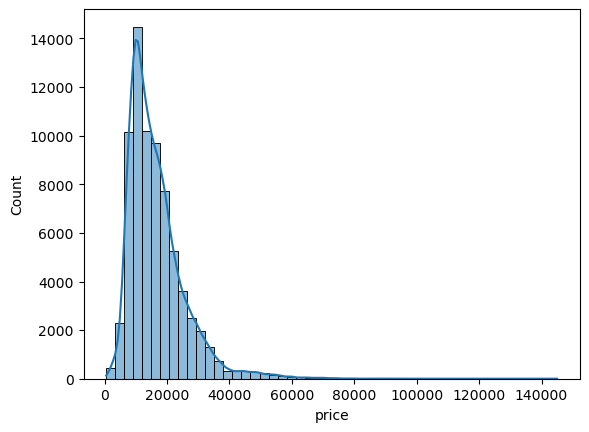

In [101]:
# analyze the distribution of the target variable
sns.histplot(df['price'], bins=50, kde=True)
plt.show()

In [102]:
priceCounts = df['price'].value_counts()
priceCounts

price
9995     446
8995     379
11995    350
10995    346
12995    346
        ... 
27016      1
28994      1
58994      1
50495      1
3095       1
Name: count, Length: 10418, dtype: int64

## Preprocessing

In [103]:
columns2drop = ['model', 'tax']
df.drop(columns=columns2drop, inplace=True)

In [104]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
enc = LabelEncoder()
df['fuelType'] = enc.fit_transform(df['fuelType'])
df['transmission'] = enc.fit_transform(df['transmission'])

In [105]:
df

,year,price,transmission,mileage,fuelType,mpg,engineSize,Make
0,2017,12500,1,15735,4,55.4,1.4,audi
1,2016,16500,0,36203,0,64.2,2.0,audi
2,2016,11000,1,29946,4,55.4,1.4,audi
3,2017,16800,0,25952,0,67.3,2.0,audi
4,2019,17300,1,1998,4,49.6,1.0,audi
...,...,...,...,...,...,...,...,...
72430,2016,8680,1,25906,0,78.4,1.6,Hyundai
72431,2015,7830,1,59508,0,65.7,1.7,Hyundai
72432,2017,6830,1,13810,4,60.1,1.0,Hyundai
72433,2018,13994,1,23313,4,44.8,1.6,Hyundai


In [106]:
encoder = OneHotEncoder(sparse_output=False)
columns2encode = ['Make']
encoded_data = encoder.fit_transform(df[columns2encode])
encoder.categories_

[array(['BMW', 'Ford', 'Hyundai', 'audi', 'skoda', 'toyota', 'vw'],
       dtype=object)]

In [107]:
feature_names = encoder.get_feature_names_out(columns2encode)
encoded_df = pd.DataFrame(encoded_data, columns=feature_names)
df2 = pd.concat([df.drop(columns=columns2encode), encoded_df], axis=1)
df2.head()

,year,price,transmission,mileage,fuelType,mpg,engineSize,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,12500,1,15735,4,55.4,1.4,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2016,16500,0,36203,0,64.2,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2016,11000,1,29946,4,55.4,1.4,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2017,16800,0,25952,0,67.3,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2019,17300,1,1998,4,49.6,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Linear regression

In [108]:
from sklearn.linear_model import LinearRegression

In [109]:
model = LinearRegression()
model.fit(df2.drop(columns=['price']), df2['price'])


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [110]:
Y_pred = model.predict(df2.drop(columns=['price']))

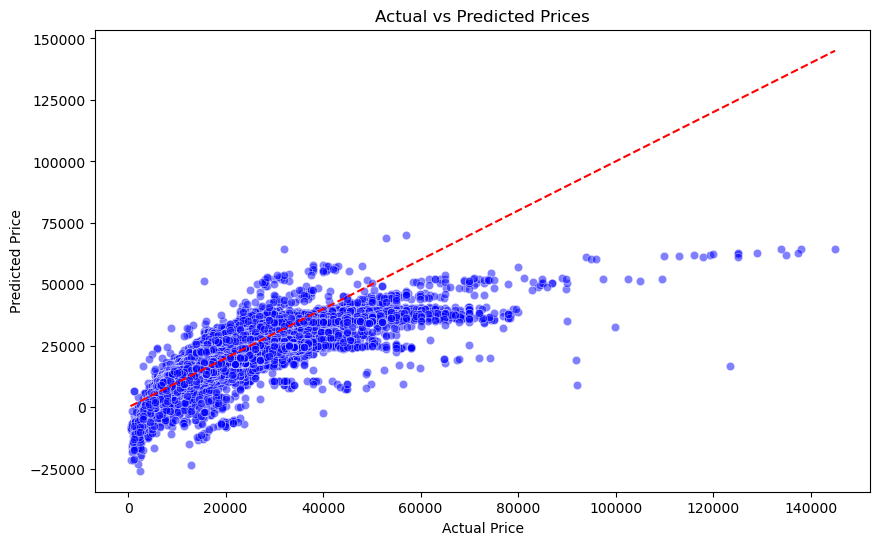

In [111]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df2['price'], y=Y_pred, color='blue', alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.plot([df2['price'].min(), df2['price'].max()], [df2['price'].min(), df2['price'].max()], 'r--')
plt.show()

### Linear Regression Line
The goal of this line is to find the best fit line that minimizes the sum of squared errors between the predicted values and the actual values.

In [112]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -3140603.1760885837
Coefficients: [ 1.55796104e+03  2.22158532e+02 -9.77754041e-02  3.11657896e+02
 -1.65730275e+01  1.01456492e+04  1.48439539e+03 -8.51712919e+02
 -2.05427852e+03  3.70760590e+03 -1.06601460e+03 -1.64808930e+03
  4.28094048e+02]


In [113]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

mse = mean_squared_error(df2['price'], Y_pred)
r2 = r2_score(df2['price'], Y_pred)
mae = mean_absolute_error(df2['price'], Y_pred)
mape = mean_absolute_percentage_error(df2['price'], Y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)

Mean Squared Error: 21826044.856900074
R-squared: 0.747590406203019
Mean Absolute Error: 3037.722387356503
Mean Absolute Percentage Error: 0.22849975033804457


In [114]:
X_test = df2.drop(columns=['price']).values
print(1-(1-r2_score(df2['price'], Y_pred))*((len(X_test)-1)/(len(X_test)-len(X_test[0])-1)))

0.7475450971805067


## Random Forest

With the current dataset, we can expect a linear regression model to perform reasonably well, as there are no complex interactions between the features. However, a random forest model may perform better, as it can capture non-linear relationships between the features and the target variable (price). Additionally, random forests are less sensitive to outliers and can handle unbalanced datasets better than linear regression. Therefore, I would expect the random forest model to outperform the linear regression model on this dataset.

In [115]:
df2.head()

,year,price,transmission,mileage,fuelType,mpg,engineSize,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,12500,1,15735,4,55.4,1.4,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2016,16500,0,36203,0,64.2,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2016,11000,1,29946,4,55.4,1.4,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2017,16800,0,25952,0,67.3,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2019,17300,1,1998,4,49.6,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


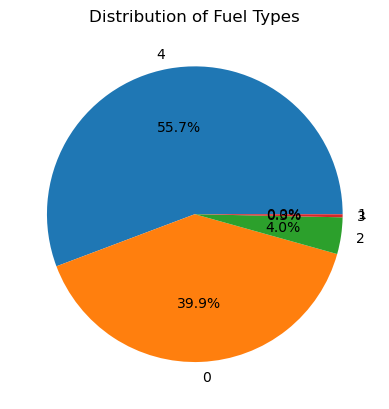

In [116]:
plt.pie(df2['fuelType'].value_counts(), labels=df2['fuelType'].unique(), autopct='%1.1f%%')
plt.title('Distribution of Fuel Types')
plt.show()

In [117]:
from sklearn.ensemble import RandomForestRegressor

y = df2['price']
X = df2.drop(columns=['price'])

from sklearn.model_selection import train_test_split
# For a continuous target (price), do not use stratify directly on y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )

model.fit(X_train, y_train)



,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [118]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error: 7111913.9028
R² Score: 0.9198


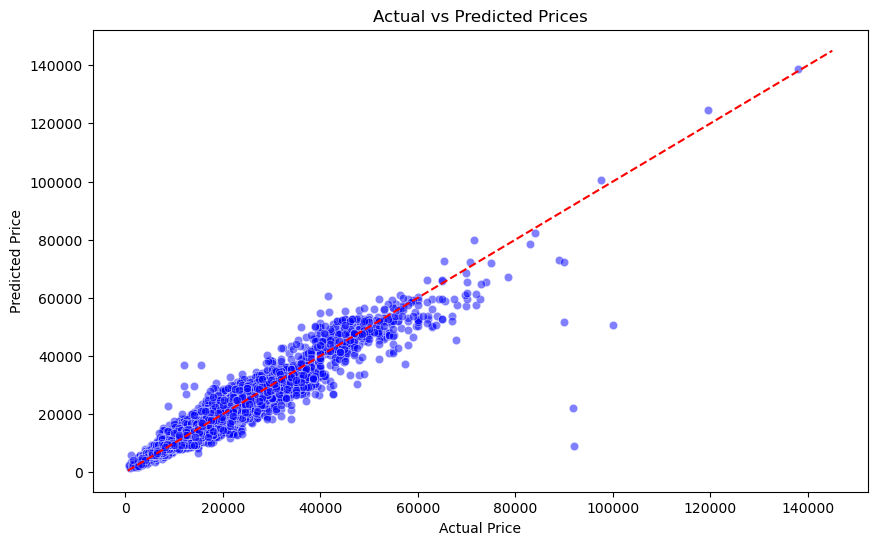

In [119]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.plot([df2['price'].min(), df2['price'].max()], [df2['price'].min(), df2['price'].max()], 'r--')
plt.show()

In [120]:
print(1-(1-r2_score(y_test, y_pred))*((len(X_test.values)-1)/(len(X_test.values)-len(X_test.values[0])-1)))

0.9196971227919686


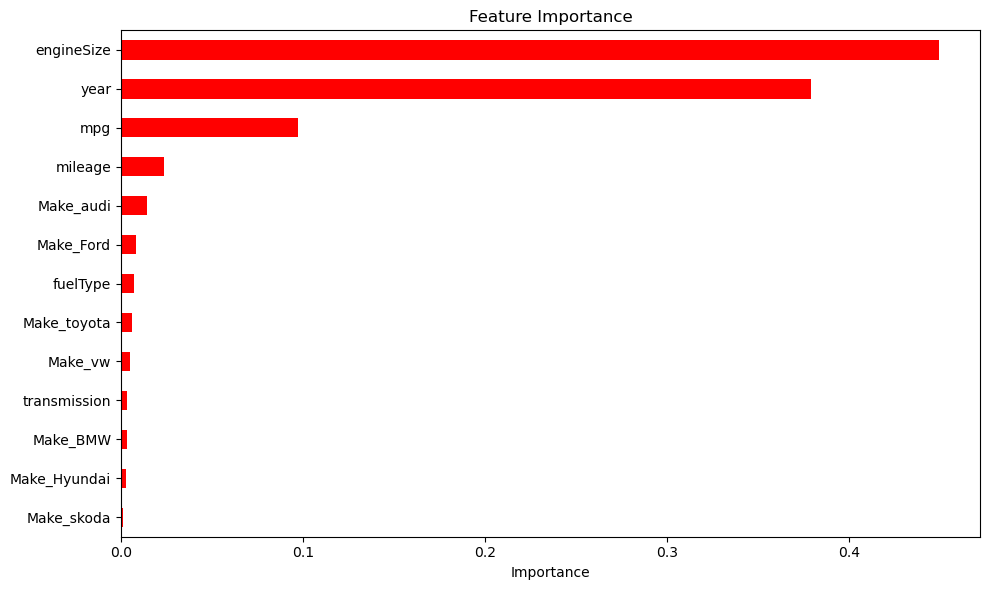

In [121]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='r')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Training

In [122]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

In [123]:
results_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

def evaluate_model(real, predicted):
    _accuracy = accuracy_score(real, predicted)
    _precision = precision_score(real, predicted)
    _recall = recall_score(real, predicted)
    _f1 = f1_score(real, predicted)
    return _accuracy, _precision, _recall, _f1
    
def print_evaluation(model, real, predicted):
    accuracy, precision, recall, f1 = evaluate_model(real, predicted)
    print(f"Model: {model}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    results = np.array([model, accuracy, precision, recall, f1])
    results_df.loc[len(results_df)] = results

## XGBoost

In [124]:
import xgboost as xgb
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

y = df2['price']
X = df2.drop(columns=['price'])

from sklearn.model_selection import train_test_split
# For a continuous target (price), do not use stratify directly on y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Creating an XGBoost regressor
model = xgb.XGBRegressor()

#Training the model on the training data
model.fit(X_train, y_train)

#Making predictions on the test set
predictions = model.predict(X_test)

# Calculate the mean squared error and R-squared score
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

Mean Squared Error: 5172984.0
R-squared Score: 0.9416426420211792


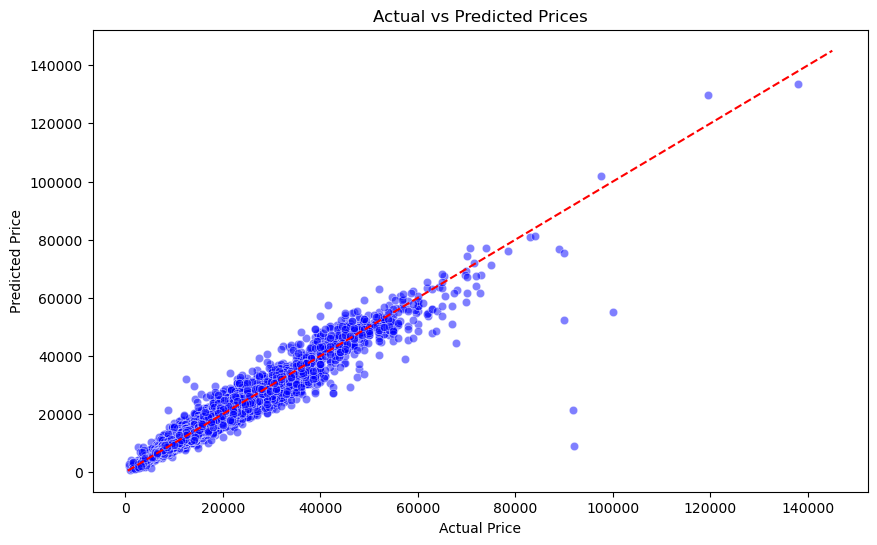

In [125]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, color='blue', alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.plot([df2['price'].min(), df2['price'].max()], [df2['price'].min(), df2['price'].max()], 'r--')
plt.show()

In [126]:
print(1-(1-r2_score(y_test, predictions))*((len(X_test.values)-1)/(len(X_test.values)-len(X_test.values[0])-1)))

0.9415902240253439


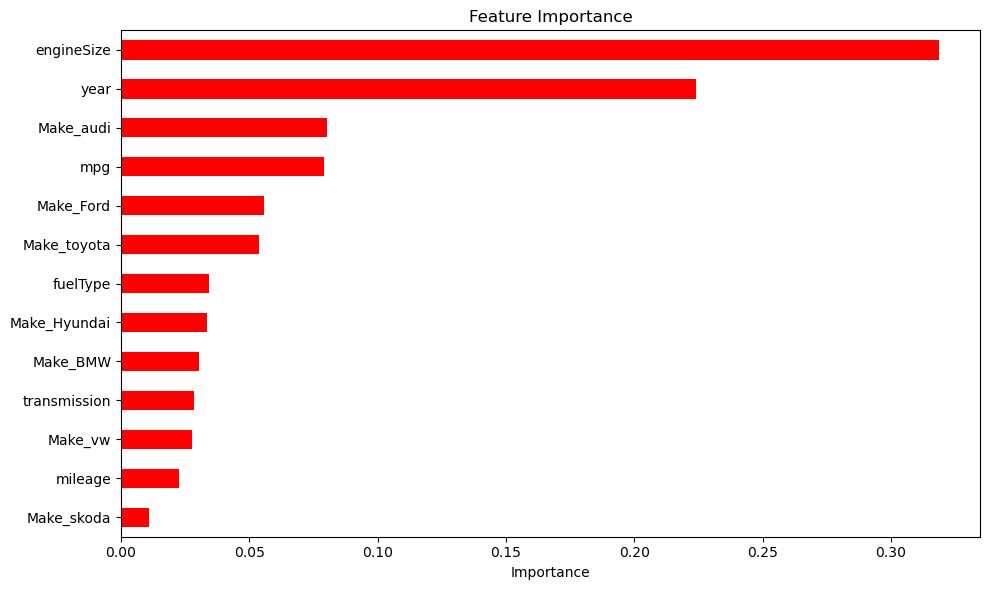

In [127]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='r')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()